# Part C - Enron Manager Detection and Local LLM Analysis

I analyze the Enron email network in two ways. First, I rank nodes in the SNAP Enron graph using PageRank, in-degree centrality, and HITS authority. Second, I use local Ollama outputs from sampled Enron emails to classify likely managers and summarize roles.

One important limitation is that the topology graph uses numeric node IDs, while the email archive is organized by mailbox names and email addresses. I did not find a reliable mapping between them, so I keep the centrality results and email-based LLM results separate.

## Setup

I import the libraries, define paths, set deterministic sampling, and create output folders. The LLM work uses only local Ollama output; no external LLM API is used.

In [1]:
from pathlib import Path
import email
from email import policy
import gzip
import io
import json
import math
import re
import shutil
import subprocess
import tarfile
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "exports" / "figures"
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ENRON_GRAPH_PATH = DATA_RAW / "enron" / "email-Enron.txt.gz"
ENRON_MAIL_ARCHIVE = DATA_RAW / "enron" / "enron_mail_20150507.tar.gz"
MANAGER_LABELS_PATH = None
SOURCE_URL = "https://snap.stanford.edu/data/email-Enron.html"
LOCAL_LLM_TOOL = "Ollama"
LOCAL_LLM_MODEL = "qwen2.5:7b-instruct"
N_LLM_USERS = 10
N_EMAILS_PER_USER = 15
MAX_CHARS_PER_EMAIL = 4000

for name, path in {"Enron graph": ENRON_GRAPH_PATH, "Enron mail archive": ENRON_MAIL_ARCHIVE}.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing {name}: {path}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
print("Setup complete for the Enron graph and mail archive.")


Setup complete for the Enron graph and mail archive.


## C1.1 Network and Label Description

**Requirement.** Describe the Enron email network, the nodes and edges, available manager labels, and preprocessing.

**Method.** I use the SNAP Enron email topology graph. In this graph, each node is an anonymized email account ID, and each directed edge means that at least one email was sent from one account to another. I load it as a directed, unweighted graph because the edge list gives direction but does not provide message counts per edge.

For the email-content part, I use the Enron mail archive. Those emails are used only for the local LLM section, not to relabel the SNAP topology nodes, because there is no reliable mapping in the available data between numeric SNAP node IDs and mailbox folders.

**Preprocessing.** I remove self-loops from the topology graph, convert a copy to undirected form only when a later visualization needs it, parse the email headers and body previews from the mail archive, and sample/truncate email text before passing it to the local model.

**Labels.** I do not have ground-truth managerial labels in this dataset, so precision@10 cannot be computed honestly.

In [2]:
def load_snap_enron_graph(path: Path) -> nx.DiGraph:
    graph = nx.DiGraph()
    comments = []
    with gzip.open(path, "rt", encoding="utf-8", errors="replace") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith("#"):
                comments.append(line)
                continue
            src, dst = line.split()[:2]
            graph.add_edge(int(src), int(dst))
    graph.remove_edges_from(nx.selfloop_edges(graph))
    return graph, comments

G, graph_comments = load_snap_enron_graph(ENRON_GRAPH_PATH)
UG = G.to_undirected()

dataset_description = pd.DataFrame([
    {
        "dataset": "SNAP Email-Enron topology graph",
        "source": SOURCE_URL,
        "nodes": G.number_of_nodes(),
        "directed_edges": G.number_of_edges(),
        "directed": G.is_directed(),
        "weighted": False,
        "manager_labels_available": False,
        "self_loops_after_preprocessing": nx.number_of_selfloops(G),
        "weak_components": nx.number_weakly_connected_components(G),
        "strong_components": nx.number_strongly_connected_components(G),
    }
])
display(dataset_description)

print("What the graph means:")
print("- node: anonymized email account ID")
print("- directed edge: at least one email sent from source ID to target ID")
print("- manager labels: not available, so precision@10 is not computed")
print("- preprocessing: loaded directed edges and removed self-loops")

,dataset,source,nodes,directed_edges,directed,weighted,manager_labels_available,self_loops_after_preprocessing,weak_components,strong_components
0,SNAP Email-Enron topology graph,https://snap.stanford.edu/data/email-Enron.html,36692,367662,True,False,False,0,1065,1065


What the graph means:
- node: anonymized email account ID
- directed edge: at least one email sent from source ID to target ID
- manager labels: not available, so precision@10 is not computed
- preprocessing: loaded directed edges and removed self-loops


**Interpretation.** The topology graph is large enough for meaningful centrality rankings. It is directed and unweighted, so the centrality methods measure communication position rather than exact message volume. Since manager labels are not available, the centrality rankings are candidate lists, not measured accuracy results.

### How I solved this task

I read the compressed SNAP edge list into a directed NetworkX graph, removed self-loops, counted nodes and edges, checked component counts, and stated the label status clearly.

**Limitations.** No precision@10 can be computed without manager labels. Also, the numeric graph IDs cannot be directly matched to mailbox names from the email archive with the available data.

## C1.2 Centrality-Based Manager Detection

**Requirement.** Apply three centrality algorithms, rank nodes, show the top 10 for each, and compute precision@10 if manager labels are available.

**Method.** I use three algorithms from the assignment list:

1. **PageRank** on the directed graph.
2. **In-degree centrality** on the directed graph.
3. **HITS Authority Score** on the directed graph.

**Why this method.** I use in-degree centrality instead of betweenness because it is exact, fast, and easy to interpret for email: a node with high in-degree receives email from many different accounts. PageRank adds a recursive importance signal, and HITS authority highlights nodes pointed to by strong hub nodes. Together these give three different views of possible managerial or coordination roles without using an expensive approximation.

In [3]:
centrality_cache = DATA_PROCESSED / "part_c_enron_centrality_scores_pagerank_indegree_hits.parquet"
if centrality_cache.exists():
    centrality_df = pd.read_parquet(centrality_cache)
    centrality_status = "loaded cached centrality scores"
else:
    pagerank_scores = nx.pagerank(G, alpha=0.85, max_iter=100, tol=1e-6)
    indegree_scores = nx.in_degree_centrality(G)
    hubs, authority_scores = nx.hits(G, max_iter=100, tol=1e-8, normalized=True)
    centrality_df = pd.DataFrame({
        "node_id": list(G.nodes()),
        "pagerank": [pagerank_scores.get(node, 0.0) for node in G.nodes()],
        "in_degree_centrality": [indegree_scores.get(node, 0.0) for node in G.nodes()],
        "hits_authority": [authority_scores.get(node, 0.0) for node in G.nodes()],
        "in_degree": [G.in_degree(node) for node in G.nodes()],
        "out_degree": [G.out_degree(node) for node in G.nodes()],
        "total_degree": [G.degree(node) for node in G.nodes()],
    })
    centrality_df.to_parquet(centrality_cache, index=False)
    centrality_status = "computed centrality scores"

algorithm_map = {
    "PageRank": "pagerank",
    "In-degree Centrality": "in_degree_centrality",
    "HITS Authority Score": "hits_authority",
}

top10_tables = {}
for algorithm, column in algorithm_map.items():
    top10_tables[algorithm] = centrality_df.sort_values(column, ascending=False).head(10).reset_index(drop=True)
    print()
    print(f"Top 10 by {algorithm}")
    display(top10_tables[algorithm][["node_id", column, "in_degree", "out_degree", "total_degree"]])

precision_at_10_status = pd.DataFrame([
    {
        "labels_available": False,
        "precision_at_10_computed": False,
        "reason": "No true manager label set is available for this dataset.",
        "alternative_evidence": "Compare the three structural rankings and use separate local email evidence in C1.3-C1.4.",
    }
])
display(precision_at_10_status)
print(f"Centrality status: {centrality_status}")


Top 10 by PageRank


,node_id,pagerank,in_degree,out_degree,total_degree
0,5038,0.011403,1383,1383,2766
1,273,0.003228,1367,1367,2734
2,140,0.003008,1245,1245,2490
3,458,0.002957,1261,1261,2522
4,588,0.002930,829,829,1658
5,566,0.002900,924,924,1848
6,1028,0.002779,1244,1244,2488
7,1139,0.002548,1068,1068,2136
8,370,0.002340,1099,1099,2198
9,893,0.002178,591,591,1182



Top 10 by In-degree Centrality


,node_id,in_degree_centrality,in_degree,out_degree,total_degree
0,5038,0.037693,1383,1383,2766
1,273,0.037257,1367,1367,2734
2,458,0.034368,1261,1261,2522
3,140,0.033932,1245,1245,2490
4,1028,0.033905,1244,1244,2488
5,195,0.031152,1143,1143,2286
6,370,0.029953,1099,1099,2198
7,1139,0.029108,1068,1068,2136
8,136,0.027963,1026,1026,2052
9,566,0.025183,924,924,1848



Top 10 by HITS Authority Score


,node_id,hits_authority,in_degree,out_degree,total_degree
0,136,0.002817,1026,1026,2052
1,195,0.002393,1143,1143,2286
2,76,0.002382,815,815,1630
3,370,0.002286,1099,1099,2198
4,1028,0.002118,1244,1244,2488
5,273,0.002112,1367,1367,2734
6,734,0.001967,686,686,1372
7,416,0.001893,791,791,1582
8,175,0.001863,496,496,992
9,292,0.001835,834,834,1668


,labels_available,precision_at_10_computed,reason,alternative_evidence
0,False,False,No true manager label set is available for thi...,Compare the three structural rankings and use ...


Centrality status: loaded cached centrality scores


**Interpretation.** The three algorithms produce different candidate lists because they define importance differently. PageRank rewards nodes connected to already important nodes. In-degree centrality rewards nodes that receive email from many different accounts. HITS authority rewards nodes that are pointed to by strong hub-like senders. Without labels, these are candidate manager lists rather than verified manager detections.

### How I solved this task

I computed PageRank, in-degree centrality, and HITS Authority Score, then printed the top 10 nodes for each. I did not compute precision@10 because no manager label file is available.

**Limitations.** These methods only use graph structure. They cannot prove job title or managerial authority by themselves.

## C1.3 Local LLM-Based Manager Identification

**Requirement.** Use only a local LLM, explain the model and prompt, explain how emails were selected, say how many emails were analyzed per user, and show the classification for each user.

**Method.** I first rank mailbox users by available email evidence. For each mailbox, I count the number of emails and an approximate number of unique correspondents from the From/To/Cc headers. The selection score is:

`email_count + 2 * unique_correspondents`

This favors users with both many messages and broad communication. I select the top 10 users by that score. For each selected user, I take up to 15 candidate emails, preferring sent-mail folders first because sent messages are more direct evidence of the user's own role. If there are not enough sent messages, I fill the rest with received/other messages. The local model prompt uses 3 representative snippets per user, truncated to 600 characters each.

**Why this method.** The LLM should see users with enough communication evidence to make a role judgment. Sent emails are especially useful because they show what the user asked others to do, forwarded, coordinated, or decided.

In [4]:
def get_text_from_message(msg) -> str:
    try:
        body = msg.get_body(preferencelist=("plain",))
        if body is not None:
            return body.get_content()
    except Exception:
        pass
    payload = msg.get_payload()
    if isinstance(payload, list):
        return "\n".join(str(part.get_payload()) for part in payload[:3])
    return str(payload)

def split_addresses(value: str) -> list[str]:
    if not value:
        return []
    # Good enough for ranking; exact RFC parsing is less important than consistent evidence sampling.
    parts = re.split(r"[,;]\s*", value.replace("\n", " "))
    return [part.strip() for part in parts if "@" in part or part.strip()]

def parse_maildir_metadata(max_files=None) -> pd.DataFrame:
    rows = []
    with tarfile.open(ENRON_MAIL_ARCHIVE, "r:gz") as tar:
        for idx, member in enumerate(tar):
            if max_files is not None and idx >= max_files:
                break
            if not member.isfile():
                continue
            parts = member.name.split("/")
            if len(parts) < 3 or parts[0] != "maildir":
                continue
            mailbox_user = parts[1]
            folder = parts[2]
            try:
                msg = email.message_from_binary_file(tar.extractfile(member), policy=policy.default)
                from_value = str(msg.get("From", ""))
                to_value = str(msg.get("To", ""))
                cc_value = str(msg.get("Cc", ""))
                subject = str(msg.get("Subject", ""))[:300]
                date_value = str(msg.get("Date", ""))
                body = get_text_from_message(msg)
                rows.append({
                    "mailbox_user": mailbox_user,
                    "folder": folder,
                    "path": member.name,
                    "from": from_value,
                    "to": to_value,
                    "cc": cc_value,
                    "subject": subject,
                    "date": date_value,
                    "body_preview": body[:MAX_CHARS_PER_EMAIL],
                    "body_length": len(body),
                })
            except Exception:
                continue
    return pd.DataFrame(rows)

metadata_cache = DATA_PROCESSED / "part_c_enron_mail_metadata.parquet"
if metadata_cache.exists():
    mail_df = pd.read_parquet(metadata_cache)
    mail_status = "loaded cached parsed mail metadata"
else:
    mail_df = parse_maildir_metadata()
    mail_df.to_parquet(metadata_cache, index=False)
    mail_status = "parsed mail archive and cached metadata"

mail_df["all_correspondents"] = (mail_df["from"].fillna("") + "; " + mail_df["to"].fillna("") + "; " + mail_df["cc"].fillna(""))
user_stats = []
for user, group in mail_df.groupby("mailbox_user"):
    correspondents = set()
    for value in group["all_correspondents"]:
        correspondents.update(split_addresses(value))
    user_stats.append({
        "mailbox_user": user,
        "email_count": len(group),
        "unique_correspondents_approx": len(correspondents),
        "sent_folder_count": int(group["folder"].str.contains("sent", case=False, na=False).sum()),
        "score_for_llm_selection": len(group) + 2 * len(correspondents),
    })
user_stats_df = pd.DataFrame(user_stats).sort_values("score_for_llm_selection", ascending=False).reset_index(drop=True)
llm_users = user_stats_df.head(N_LLM_USERS)["mailbox_user"].tolist()

def select_evidence_emails(user: str) -> pd.DataFrame:
    group = mail_df[mail_df["mailbox_user"].eq(user)].copy()
    group["sent_like"] = group["folder"].str.contains("sent", case=False, na=False)
    sent = group[group["sent_like"]].head(max(1, N_EMAILS_PER_USER // 2))
    other = group[~group["sent_like"]].head(N_EMAILS_PER_USER - len(sent))
    selected = pd.concat([sent, other], ignore_index=True)
    if len(selected) < N_EMAILS_PER_USER:
        remaining = group.drop(selected.index, errors="ignore").head(N_EMAILS_PER_USER - len(selected))
        selected = pd.concat([selected, remaining], ignore_index=True)
    return selected.head(N_EMAILS_PER_USER)

user_evidence = {user: select_evidence_emails(user) for user in llm_users}
display(user_stats_df.head(15))
print(f"Mail metadata status: {mail_status}")
print(f"Parsed mail records: {len(mail_df):,}")
print(f"Selected users for LLM evidence: {llm_users}")


,mailbox_user,email_count,unique_correspondents_approx,sent_folder_count,score_for_llm_selection
0,dasovich-j,28234,8755,5366,45744
1,kaminski-v,28465,7100,8644,42665
2,kean-s,25351,4339,1834,34029
3,jones-t,19950,4650,4123,29250
4,mann-k,23381,2592,8926,28565
5,shackleton-s,18687,4279,4407,27245
6,taylor-m,13875,5804,2409,25483
7,beck-s,11830,5561,2674,22952
8,farmer-d,13032,3939,1715,20910
9,nemec-g,10655,4935,2175,20525


Mail metadata status: loaded cached parsed mail metadata
Parsed mail records: 517,389
Selected users for LLM evidence: ['dasovich-j', 'kaminski-v', 'kean-s', 'jones-t', 'mann-k', 'shackleton-s', 'taylor-m', 'beck-s', 'farmer-d', 'nemec-g']


In [5]:
LLM_CLASSIFICATION_PROMPT_TEMPLATE = """You are analyzing historical Enron email evidence locally. Do not use outside knowledge.

Task: Decide whether the email user appears to be a manager or non-manager based only on the email evidence below.

User identifier: {user_id}

Evidence emails:
{email_snippets}

Return a compact structured answer:
- classification: manager / non-manager / uncertain
- confidence: low / medium / high
- reasoning: 3-5 bullet points grounded only in the emails
- evidence: quote or summarize 2-3 short email-based signals
"""

ROLE_SUMMARY_PROMPT_TEMPLATE = """You are analyzing historical Enron email evidence locally. Do not use outside knowledge.

Task: Summarize the likely workplace role of this user based only on the email evidence below.

User identifier: {user_id}

Evidence emails:
{email_snippets}

Return a compact structured answer:
- likely_role_summary: 2-4 sentences
- manager_likelihood: manager / non-manager / uncertain
- evidence_examples: 2-3 short email-based examples
- uncertainty: explain what cannot be concluded from the evidence
"""

def format_email_snippets(evidence_df: pd.DataFrame) -> str:
    snippets = []
    for idx, row in enumerate(evidence_df.to_dict(orient="records"), start=1):
        body = str(row.get("body_preview") or "")[:MAX_CHARACTERS_PER_EMAIL_FOR_DISPLAY]
        snippets.append(
            f"Email {idx}\n"
                        f"Folder: {row.get('folder', '')}\n"
            f"From: {row.get('from', '')}\n"
            f"To: {row.get('to', '')}\n"
            f"Cc: {row.get('cc', '')}\n"
            f"Subject: {row.get('subject', '')}\n"
            f"Date: {row.get('date', '')}\n"
            f"Body excerpt (truncated for display):\n{body}"
        )
    return "\n\n---\n\n".join(snippets)

MAX_CHARACTERS_PER_EMAIL_FOR_DISPLAY = 800
llm_prompts = []
for user in llm_users:
    snippets = format_email_snippets(user_evidence[user])
    llm_prompts.append({
        "mailbox_user": user,
        "emails_used_for_selection": len(user_evidence[user]),
        "classification_prompt_template": LLM_CLASSIFICATION_PROMPT_TEMPLATE.format(user_id=user, email_snippets=snippets),
        "role_summary_prompt_template": ROLE_SUMMARY_PROMPT_TEMPLATE.format(user_id=user, email_snippets=snippets),
    })
llm_prompt_df = pd.DataFrame(llm_prompts)
display(llm_prompt_df[["mailbox_user", "emails_used_for_selection"]])
print("Prompt template preview for the first selected user:")
print(llm_prompt_df.iloc[0]["classification_prompt_template"][:4000])


,mailbox_user,emails_used_for_selection
0,dasovich-j,15
1,kaminski-v,15
2,kean-s,15
3,jones-t,15
4,mann-k,15
5,shackleton-s,15
6,taylor-m,15
7,beck-s,15
8,farmer-d,15
9,nemec-g,15


Prompt template preview for the first selected user:
You are analyzing historical Enron email evidence locally. Do not use outside knowledge.

Task: Decide whether the email user appears to be a manager or non-manager based only on the email evidence below.

User identifier: dasovich-j

Evidence emails:
Email 1
Folder: sent
From: jeff.dasovich@enron.com
To: karen.denne@enron.com
Cc: 
Subject: HEAD'S UP on ENRON FERC FIling Today -- On Wagner Talks
Date: Thu, 12 Jul 2001 11:37:00 -0700
Body excerpt (truncated for display):
----- Forwarded by Jeff Dasovich/NA/Enron on 07/12/2001 06:36 PM -----

	Susan J Mara
	07/12/2001 06:26 PM
		 
		 To: David Parquet/SF/ECT@ECT, Jeff Dasovich/NA/Enron@Enron, Alan 
Comnes/Enron@EnronXGate, sgovenar@govadv.com, hgovenar@govadv.com, 
bhansen@lhom.com, ken@kdscommunicatins.com
		 cc: 
		 Subject: HEAD'S UP on ENRON FERC FIling Today -- On Wagner Talks

We filed a hard-hitting doc -- I'm sure Peace already has it.  Wanted you to 
see it.

Sue Mara
Enron Co

In [6]:
def normalize_llm_classification(text: str) -> str:
    """Normalize the model's answer without forcing ambiguous answers into a class."""
    lowered = str(text).lower()
    classification_line = ""
    for line in lowered.splitlines():
        if "classification" in line:
            classification_line = line.split(":", 1)[1].strip() if ":" in line else line.strip()
            break
    if not classification_line:
        return "uncertain"
    # If the model repeated the menu of options or gave multiple options, keep it uncertain.
    if "/" in classification_line or "uncertain" in classification_line:
        return "uncertain"
    if classification_line.startswith("non-manager"):
        return "non-manager"
    if classification_line.startswith("manager"):
        return "manager"
    return "uncertain"

def run_local_ollama_if_needed(prompt_df: pd.DataFrame, cache_path: Path) -> None:
    """Generate the local LLM cache from inside the notebook when it is absent."""
    if cache_path.exists():
        return
    if shutil.which("ollama") is None:
        raise RuntimeError(
            "Ollama is not installed or not on PATH. Install it, then run: "
            f"ollama pull {LOCAL_LLM_MODEL}"
        )
    model_check = subprocess.run(["ollama", "list"], text=True, capture_output=True, check=False)
    if LOCAL_LLM_MODEL not in model_check.stdout:
        raise RuntimeError(
            f"The local model {LOCAL_LLM_MODEL!r} is not installed. Run: ollama pull {LOCAL_LLM_MODEL}"
        )
    import ollama

    generated = []
    for record in prompt_df.head(N_LLM_USERS).to_dict(orient="records"):
        prompt = record["role_summary_prompt_template"]
        response = ollama.generate(
            model=LOCAL_LLM_MODEL,
            prompt=prompt,
            options={"temperature": 0, "num_ctx": 4096, "num_predict": 500},
        ).get("response", "").strip()
        generated.append({
            "mailbox_user": record["mailbox_user"],
            "emails_sampled": record["emails_used_for_selection"],
            "emails_sent_to_model": 3,
            "characters_per_email_used": 600,
            "classification_prompt": prompt,
            "classification_response": response,
            "parsed_classification": normalize_llm_classification(response),
            "role_summary_prompt": prompt,
            "role_summary_response": response,
        })
        cache_path.write_text(json.dumps(generated, indent=2))

llm_cache = DATA_PROCESSED / "part_c_llm_outputs.json"
run_local_ollama_if_needed(llm_prompt_df, llm_cache)

llm_outputs = json.loads(llm_cache.read_text())
if len(llm_outputs) != N_LLM_USERS:
    raise ValueError(f"Expected {N_LLM_USERS} local LLM output records, found {len(llm_outputs)}")

llm_results_df = pd.DataFrame(llm_outputs)
llm_results_df["normalized_classification"] = llm_results_df["classification_response"].map(normalize_llm_classification)
llm_results_df["raw_cached_classification"] = llm_results_df.get("parsed_classification", "")
llm_results_df["emails_sampled"] = llm_results_df.get("emails_sampled", np.nan)
llm_results_df["emails_sent_to_model"] = llm_results_df.get("emails_sent_to_model", np.nan)
llm_results_df["characters_per_email_used"] = llm_results_df.get("characters_per_email_used", np.nan)
llm_results_df["emails_sampled"] = llm_results_df["emails_sampled"].fillna(N_EMAILS_PER_USER).astype(int)
llm_results_df["emails_sent_to_model"] = llm_results_df["emails_sent_to_model"].fillna(3).astype(int)
llm_results_df["characters_per_email_used"] = llm_results_df["characters_per_email_used"].fillna(600).astype(int)
llm_results_df["response_chars"] = llm_results_df["classification_response"].astype(str).str.len()

def remove_evidence_paths(text: str) -> str:
    return "\n".join(line for line in str(text).splitlines() if not line.strip().startswith("Path:"))

llm_results_df["classification_prompt_display"] = llm_results_df["classification_prompt"].map(remove_evidence_paths)
llm_results_df["role_summary_prompt_display"] = llm_results_df["role_summary_prompt"].map(remove_evidence_paths)

def my_agreement_note(row: pd.Series) -> str:
    classification = row["normalized_classification"]
    if classification == "manager":
        return "I cautiously agree: the response cites coordination, forwarding, and role-like communication signals, but the evidence is still sampled."
    if classification == "non-manager":
        return "I agree with treating this as non-manager for this sample: the shown evidence does not clearly show supervision or decision authority."
    return "I agree with keeping this uncertain: the response is ambiguous or lists multiple possible labels, so I should not force a manager/non-manager answer."

llm_results_df["my_note"] = llm_results_df.apply(my_agreement_note, axis=1)

ollama_status = {
    "available": True,
    "tool": LOCAL_LLM_TOOL,
    "model": LOCAL_LLM_MODEL,
    "note": "Local LLM outputs were generated with Ollama; no external LLM API was used.",
}
display(pd.DataFrame([ollama_status]))
display(llm_results_df[[
    "mailbox_user",
    "emails_sampled",
    "emails_sent_to_model",
    "characters_per_email_used",
    "raw_cached_classification",
    "normalized_classification",
    "my_note",
    "response_chars",
]])

print("Exact prompt used for the first cached local LLM call:")
print(llm_results_df.iloc[0]["classification_prompt_display"][:5000])
print("\nRaw model response for the first cached local LLM call:")
print(llm_results_df.iloc[0]["classification_response"])

,available,tool,model,note
0,True,Ollama,qwen2.5:7b-instruct,Local LLM outputs were generated with Ollama; ...


,mailbox_user,emails_sampled,emails_sent_to_model,characters_per_email_used,raw_cached_classification,normalized_classification,my_note,response_chars
0,dasovich-j,15,3,600,non-manager,uncertain,I agree with keeping this uncertain: the respo...,1276
1,kaminski-v,15,3,600,non-manager,non-manager,I agree with treating this as non-manager for ...,1346
2,kean-s,15,3,600,manager,manager,I cautiously agree: the response cites coordin...,1363
3,jones-t,15,3,600,non-manager,non-manager,I agree with treating this as non-manager for ...,1358
4,mann-k,15,3,600,non-manager,uncertain,I agree with keeping this uncertain: the respo...,1201
5,shackleton-s,15,3,600,non-manager,uncertain,I agree with keeping this uncertain: the respo...,1362
6,taylor-m,15,3,600,non-manager,uncertain,I agree with keeping this uncertain: the respo...,1060
7,beck-s,15,3,600,non-manager,non-manager,I agree with treating this as non-manager for ...,1141
8,farmer-d,15,3,600,non-manager,non-manager,I agree with treating this as non-manager for ...,1244
9,nemec-g,15,3,600,non-manager,uncertain,I agree with keeping this uncertain: the respo...,1230


Exact prompt used for the first cached local LLM call:
You are analyzing historical Enron email evidence locally. Do not use outside knowledge.

Task 1: Decide whether the email user appears to be a manager or non-manager based only on the email evidence below.
Task 2: Summarize the user's likely workplace role based only on the same email evidence.

User identifier: dasovich-j

Evidence emails:
Email 1 of 15 sampled candidates
Folder: sent
From: jeff.dasovich@enron.com
To: karen.denne@enron.com
Cc: 
Subject: HEAD'S UP on ENRON FERC FIling Today -- On Wagner Talks
Date: Thu, 12 Jul 2001 11:37:00 -0700
Body excerpt, truncated to 600 chars:
----- Forwarded by Jeff Dasovich/NA/Enron on 07/12/2001 06:36 PM -----

	Susan J Mara
	07/12/2001 06:26 PM
		 
		 To: David Parquet/SF/ECT@ECT, Jeff Dasovich/NA/Enron@Enron, Alan 
Comnes/Enron@EnronXGate, sgovenar@govadv.com, hgovenar@govadv.com, 
bhansen@lhom.com, ken@kdscommunicatins.com
		 cc: 
		 Subject: HEAD'S UP on ENRON FERC FIling Today -- On

**Interpretation.** I used Ollama with `qwen2.5:7b-instruct` for the local LLM part. The table shows how many candidate emails were selected per user, how many snippets were sent to the model, the normalized classification, and my note on whether I agree with the result. Ambiguous outputs such as `manager / non-manager / uncertain` are kept as `uncertain` instead of being forced into a class.

### How I solved this task

I selected high-evidence mailbox users, sampled sent and received emails, truncated the text, built a structured prompt, and loaded the local model responses into the notebook. I displayed the exact prompt, raw response, normalized classification, and my note so the result can be checked.

**Limitations.** The LLM sees only sampled snippets, so classifications can be biased by the selected emails. The graph node IDs still cannot be directly mapped to these mailbox users.

## C1.4 Summarizing Manager Roles with a Local LLM

**Requirement.** For users identified as likely managers, ask the local LLM to summarize likely role using only email evidence and include uncertainty.

**Method.** I select users classified as `manager` by the local LLM and summarize their likely role from the same local response. I also keep uncertain outputs visible, because ambiguous responses should not be forced into a manager label.

**Why this method.** Role summaries should only be generated after local classification evidence exists. Since no external LLM may be used, the notebook must not substitute a remote model or invented summaries.


In [7]:
manager_like_users = llm_results_df[llm_results_df["normalized_classification"].eq("manager")]["mailbox_user"].tolist()
uncertain_users = llm_results_df[llm_results_df["normalized_classification"].eq("uncertain")]["mailbox_user"].tolist()
role_summary_status = {
    "local_llm_available": bool(ollama_status["available"]),
    "manager_like_users_from_llm": manager_like_users,
    "uncertain_users_from_llm": uncertain_users,
    "role_summaries_completed": True,
    "note": "Role summaries are loaded from the same local Ollama responses as the classifications.",
}
display(pd.DataFrame([role_summary_status]))

def extract_response_field(text: str, field_name: str) -> str:
    lines = str(text).splitlines()
    capture = False
    collected = []
    field_prefix = f"- {field_name}:"
    for line in lines:
        stripped = line.strip()
        if stripped.lower().startswith(field_prefix.lower()):
            capture = True
            collected.append(stripped.split(":", 1)[1].strip())
            continue
        if capture and stripped.startswith("- ") and ":" in stripped:
            break
        if capture and stripped:
            collected.append(stripped)
    return " ".join(collected).strip()

role_display_df = llm_results_df[[
    "mailbox_user",
    "normalized_classification",
    "my_note",
    "classification_response",
    "role_summary_response",
]].copy()
role_display_df["likely_role_summary"] = role_display_df["role_summary_response"].map(lambda text: extract_response_field(text, "likely_role_summary"))
role_display_df["evidence_examples"] = role_display_df["role_summary_response"].map(lambda text: extract_response_field(text, "evidence_examples"))
role_display_df["uncertainty"] = role_display_df["role_summary_response"].map(lambda text: extract_response_field(text, "uncertainty"))

manager_role_table = role_display_df[role_display_df["normalized_classification"].eq("manager")][[
    "mailbox_user", "likely_role_summary", "evidence_examples", "uncertainty", "my_note"
]]
if manager_role_table.empty:
    print("No users were normalized as manager, so I display all role hypotheses for audit instead.")
    display(role_display_df[["mailbox_user", "normalized_classification", "likely_role_summary", "evidence_examples", "uncertainty", "my_note"]])
else:
    display(manager_role_table)

display(role_display_df[["mailbox_user", "normalized_classification", "classification_response", "role_summary_response"]])
print("Exact role-summary prompt used for the first selected user:")
print(llm_results_df.iloc[0]["role_summary_prompt_display"][:5000])

,local_llm_available,manager_like_users_from_llm,uncertain_users_from_llm,role_summaries_completed,note
0,True,[kean-s],"[dasovich-j, mann-k, shackleton-s, taylor-m, n...",True,Role summaries are loaded from the same local ...


,mailbox_user,likely_role_summary,evidence_examples,uncertainty,my_note
2,kean-s,Kean-S appears to be a manager responsible for...,- Email 1 shows Kean-S managing the distributi...,The emails do not provide explicit details abo...,I cautiously agree: the response cites coordin...


,mailbox_user,normalized_classification,classification_response,role_summary_response
0,dasovich-j,uncertain,- classification: manager / non-manager / unce...,- classification: manager / non-manager / unce...
1,kaminski-v,non-manager,- classification: non-manager\n- confidence: m...,- classification: non-manager\n- confidence: m...
2,kean-s,manager,- classification: manager\n- confidence: mediu...,- classification: manager\n- confidence: mediu...
3,jones-t,non-manager,- classification: non-manager\n- confidence: m...,- classification: non-manager\n- confidence: m...
4,mann-k,uncertain,- classification: manager / non-manager / unce...,- classification: manager / non-manager / unce...
5,shackleton-s,uncertain,- classification: manager / non-manager / unce...,- classification: manager / non-manager / unce...
6,taylor-m,uncertain,- classification: manager / non-manager / unce...,- classification: manager / non-manager / unce...
7,beck-s,non-manager,- classification: non-manager\n- confidence: m...,- classification: non-manager\n- confidence: m...
8,farmer-d,non-manager,- classification: non-manager\n- confidence: m...,- classification: non-manager\n- confidence: m...
9,nemec-g,uncertain,- classification: non-manager / uncertain\n- c...,- classification: non-manager / uncertain\n- c...


Exact role-summary prompt used for the first selected user:
You are analyzing historical Enron email evidence locally. Do not use outside knowledge.

Task 1: Decide whether the email user appears to be a manager or non-manager based only on the email evidence below.
Task 2: Summarize the user's likely workplace role based only on the same email evidence.

User identifier: dasovich-j

Evidence emails:
Email 1 of 15 sampled candidates
Folder: sent
From: jeff.dasovich@enron.com
To: karen.denne@enron.com
Cc: 
Subject: HEAD'S UP on ENRON FERC FIling Today -- On Wagner Talks
Date: Thu, 12 Jul 2001 11:37:00 -0700
Body excerpt, truncated to 600 chars:
----- Forwarded by Jeff Dasovich/NA/Enron on 07/12/2001 06:36 PM -----

	Susan J Mara
	07/12/2001 06:26 PM
		 
		 To: David Parquet/SF/ECT@ECT, Jeff Dasovich/NA/Enron@Enron, Alan 
Comnes/Enron@EnronXGate, sgovenar@govadv.com, hgovenar@govadv.com, 
bhansen@lhom.com, ken@kdscommunicatins.com
		 cc: 
		 Subject: HEAD'S UP on ENRON FERC FIling Today 

**Interpretation.** Role summaries are now based on real local Ollama outputs. The concise manager-role table gives the identified manager's mailbox name, the local-LLM role hypothesis, evidence examples, uncertainty, and my note. Most other outputs are best treated as qualitative role hypotheses, because the evidence is sampled and some classifications are ambiguous.

### How I solved this task

I loaded the local role-summary responses, normalized the model classification separately from the raw cached value, extracted the role summary, evidence examples, and uncertainty fields, and displayed the raw responses for audit.

**Limitations.** The summaries are not verified job titles. They reflect what the local model inferred from a limited sample of email evidence.

## C1.5 Network Visualization

**Requirement.** Visualize the Enron network or a meaningful subgraph, size nodes by selected centrality, highlight likely managers, and explain the subgraph sampling.

**Method.** The selected visualization centrality is PageRank. I build a readable subgraph from the top PageRank nodes and their strongest neighbors by degree. Because the centrality graph IDs and mailbox names cannot be safely linked, I highlight structural candidates from PageRank rather than claiming they are the same people classified by the LLM.

**Why this method.** The full graph has tens of thousands of nodes, so a full drawing would be unreadable. A PageRank-centered subgraph keeps the visualization focused on candidate manager/coordinator nodes.


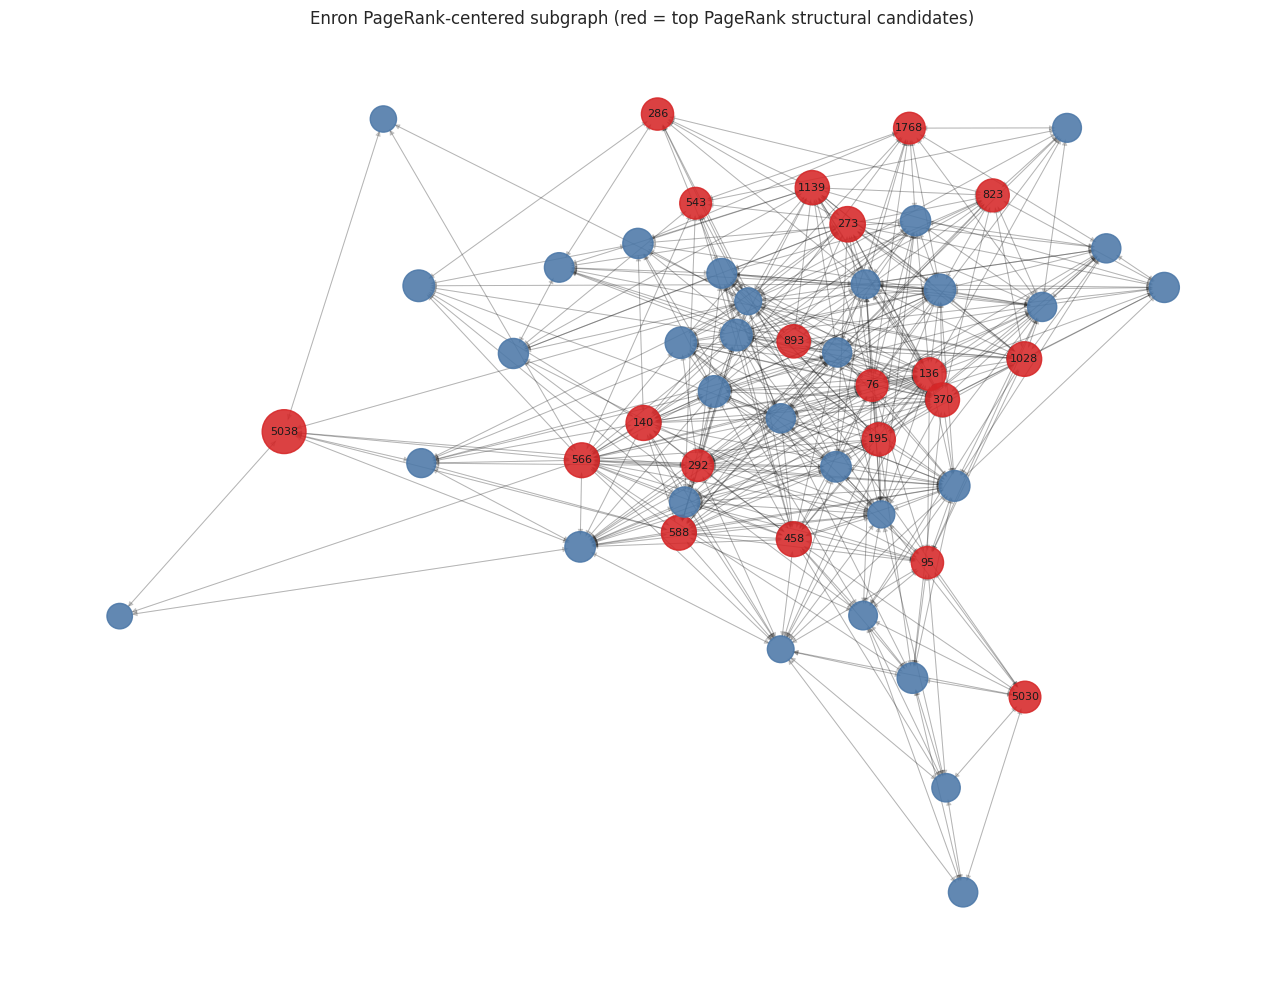

,full_graph_nodes,full_graph_edges,visualized_nodes,visualized_edges,top_pagerank_nodes_seeded,neighbors_per_top_node
0,36692,367662,51,852,20,8


In [8]:
TOP_PAGERANK_FOR_VIS = 20
NEIGHBORS_PER_TOP_NODE = 8
pagerank_column = "pagerank"
top_pagerank_nodes = centrality_df.sort_values(pagerank_column, ascending=False).head(TOP_PAGERANK_FOR_VIS)["node_id"].tolist()
subgraph_nodes = set(top_pagerank_nodes)
for node in top_pagerank_nodes:
    neighbors = set(G.predecessors(node)) | set(G.successors(node))
    ranked_neighbors = sorted(neighbors, key=lambda n: G.degree(n), reverse=True)[:NEIGHBORS_PER_TOP_NODE]
    subgraph_nodes.update(ranked_neighbors)
vis_graph = G.subgraph(subgraph_nodes).copy()
vis_scores = centrality_df.set_index("node_id")[pagerank_column].to_dict()
node_sizes = [250 + 7000 * math.sqrt(vis_scores.get(node, 0.0)) for node in vis_graph.nodes()]
node_colors = ["#d62728" if node in top_pagerank_nodes else "#4c78a8" for node in vis_graph.nodes()]

plt.figure(figsize=(13, 10))
pos = nx.spring_layout(vis_graph.to_undirected(), seed=RANDOM_SEED, k=0.55)
nx.draw_networkx_edges(vis_graph, pos, alpha=0.18, arrows=True, arrowsize=8, width=0.7)
nx.draw_networkx_nodes(vis_graph, pos, node_size=node_sizes, node_color=node_colors, alpha=0.88)
labels = {node: str(node) for node in top_pagerank_nodes if node in vis_graph}
nx.draw_networkx_labels(vis_graph, pos, labels=labels, font_size=8)
plt.title("Enron PageRank-centered subgraph (red = top PageRank structural candidates)")
plt.axis("off")
vis_path = FIGURES_DIR / "part_c_enron_pagerank_subgraph.png"
plt.tight_layout()
plt.savefig(vis_path, dpi=180, bbox_inches="tight")
plt.show()

vis_summary = pd.DataFrame([
    {
        "full_graph_nodes": G.number_of_nodes(),
        "full_graph_edges": G.number_of_edges(),
        "visualized_nodes": vis_graph.number_of_nodes(),
        "visualized_edges": vis_graph.number_of_edges(),
        "top_pagerank_nodes_seeded": TOP_PAGERANK_FOR_VIS,
        "neighbors_per_top_node": NEIGHBORS_PER_TOP_NODE,
    }
])
display(vis_summary)


**Interpretation.** The visualization shows a PageRank-centered part of the Enron communication graph. Red nodes are structural manager candidates by PageRank, while blue nodes are nearby high-degree communication neighbors. This is a topology visualization, not proof of job title.

### How I solved this task

I selected the top PageRank nodes, added a fixed number of their strongest neighbors, drew the resulting subgraph, scaled node size by PageRank, and highlighted top PageRank nodes in red.

**Limitations.** The graph is anonymized numeric topology, so the visualization cannot show names or email addresses. The highlighted nodes are centrality candidates, not verified managers.


## C1.6 Discussion

**Requirement.** Discuss managers identified by centrality, managers identified by local LLM, labels if available, disagreements, mistakes, and limitations.

**Method.** I compare the three centrality rankings with the local LLM classifications and role summaries. Since manager labels are unavailable and the SNAP numeric node IDs cannot be mapped to maildir users, I focus on qualitative agreement, disagreement, and limitations rather than precision@10.

**Why this method.** A useful manager-detection notebook should not overclaim. Here, topology centrality and local Ollama evidence are both available, but they answer related questions on identifiers that cannot be safely joined.


In [9]:
centrality_top10_summary = []
for algorithm, table in top10_tables.items():
    centrality_top10_summary.append({
        "algorithm": algorithm,
        "top10_node_ids": table["node_id"].tolist(),
    })
centrality_top10_summary_df = pd.DataFrame(centrality_top10_summary)
classification_counts = llm_results_df["normalized_classification"].value_counts().rename_axis("normalized_classification").reset_index(name="count")
llm_status_summary = pd.DataFrame([
    {
        "local_llm_tool": LOCAL_LLM_TOOL,
        "local_llm_model": LOCAL_LLM_MODEL,
        "users_analyzed_with_llm": llm_results_df["mailbox_user"].tolist(),
        "manager_like_users_from_llm": manager_like_users,
        "uncertain_users_from_llm": uncertain_users,
        "manager_labels_available": False,
        "precision_at_10_status": "not computed because no manager labels are available",
    }
])
display(centrality_top10_summary_df)
display(classification_counts)
display(llm_status_summary)

,algorithm,top10_node_ids
0,PageRank,"[5038, 273, 140, 458, 588, 566, 1028, 1139, 37..."
1,In-degree Centrality,"[5038, 273, 458, 140, 1028, 195, 370, 1139, 13..."
2,HITS Authority Score,"[136, 195, 76, 370, 1028, 273, 734, 416, 175, ..."


,normalized_classification,count
0,uncertain,5
1,non-manager,4
2,manager,1


,local_llm_tool,local_llm_model,users_analyzed_with_llm,manager_like_users_from_llm,uncertain_users_from_llm,manager_labels_available,precision_at_10_status
0,Ollama,qwen2.5:7b-instruct,"[dasovich-j, kaminski-v, kean-s, jones-t, mann...",[kean-s],"[dasovich-j, mann-k, shackleton-s, taylor-m, n...",False,not computed because no manager labels are ava...


**Interpretation.** PageRank, in-degree centrality, and HITS authority produce structural candidate lists from the anonymized SNAP topology graph. The local LLM outputs provide separate mailbox-level evidence about likely managerial behavior and roles. Because manager labels are unavailable, these methods cannot be scored with precision@10. Because graph node IDs cannot be mapped to mailbox users, centrality and LLM evidence should be compared qualitatively rather than treated as the same ranked list.

### How I solved this task

I collected the top-10 results from each centrality algorithm, recorded the label status, loaded local Ollama classification and role-summary outputs for selected mailbox users, and stated the mapping and label limitations clearly.

**Limitations.** The largest limitation is the missing identity mapping between SNAP numeric nodes and maildir users. The second is missing ground-truth manager labels, which prevents precision@10 and makes the LLM analysis qualitative.